In [94]:
import numpy as np
from scipy.signal import find_peaks, butter, filtfilt, hilbert
from joblib import Parallel, delayed
import os
import mne
import DeepNeuralNetworkSleep.hdf5_files.Artefacts_Detection as A
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [95]:
noise_band = [0,0.5]
delta_band = [0.5,5]
theta_band = [6,10]
sigma_band = [11,17]
beta_band = [22,30]
gamma_band = [8,12]
total_band = [0,30]
alpha_band = [8,12]

In [96]:
def index_R(delta, theta, sigma, EMG):
  index_r = np.array([])
  for i in range(len(delta)):
    value = (theta[i]**3)/(delta[i]*sigma[i]*EMG[i])
    index_r = np.append(index_r, [value])
  return index_r

In [97]:
def nindex_R(delta, theta, sigma, EMG, gamma):
  nindex_r = np.array([])
  for i in range(len(delta)):
    value = ((theta[i]*2)*gamma[i])/(delta[i]*delta[i]*EMG[i]**2)
    nindex_r = np.append(nindex_r, [value])
  return nindex_r

In [98]:
def alt_index_R(delta, theta, sigma, EMG, gamma, EOG1, EOG2, epoch_length, fs, alpha=0.5):
    """
    Combined REM index integrating EEG/EMG power features with EOG eye-movement features.
    
    Parameters
    ----------
    delta, theta, sigma, EMG, gamma : arrays of band powers per epoch
    EOG1, EOG2 : raw EOG signals
    epoch_length : length of each epoch in seconds
    fs : sampling rate
    alpha : weighting between EEG/EMG (power) index and EOG feature (0..1)
             higher alpha => more weight to EEG/EMG power features

    Returns
    -------
    nindex_r : numpy array of combined REM index per epoch
    """
    # --- power-based REM index ---
    nindex_r = ((theta * 2) * gamma) / (delta**2 * EMG**2 + 1e-12)

    # --- EOG-based REM feature (from your rem_feature function) ---
    b, a = butter(4, [0.3 / (0.5 * fs), 35 / (0.5 * fs)], btype='band')
    EOG1_f = filtfilt(b, a, EOG1)
    EOG2_f = filtfilt(b, a, EOG2)
    cross_cor_val = cross_correlation(EOG1_f, EOG2_f, epoch_length, fs, 0)
    auto_slope = auto_correlation_slope(EOG1_f, epoch_length, fs)

    rem_features = []
    for count, slope in enumerate(auto_slope):
        if np.isclose(slope, 0.0):
            rem_features.append(0.0)
            continue
        eog_feature = (1 / slope) * np.sign(cross_cor_val[count])
        rem_features.append(eog_feature)
    rem_features = np.array(rem_features)

    # --- align and normalize ---
    n = min(len(nindex_r), len(rem_features))
    nindex_r = nindex_r[:n]
    rem_features = rem_features[:n]

    # z-score normalization (prevents scale dominance)
    def z(x):
        return (x - np.mean(x)) / (np.std(x) + 1e-12)
    nindex_z = z(nindex_r)
    rem_z = z(rem_features)

    # if they're anticorrelated, flip sign of rem_z so they reinforce each other
    if np.corrcoef(nindex_z, rem_z)[0, 1] < 0:
        rem_z = -rem_z

    # --- fuse features ---
    combined = alpha * nindex_z + (1 - alpha) * rem_z

    return combined

In [99]:
def cross_correlation(EOG1, EOG2, epoch_length, fs, lag=0):
    samples = int(epoch_length * fs)
    cross_cor_epochs = []

    for i in range(0, len(EOG1) - len(EOG1) % samples, samples):
        epoch1 = EOG1[i:i + samples]
        epoch2 = EOG2[i:i + samples]
        cc_full = np.correlate(epoch1, epoch2, mode='full')
        center = len(cc_full) // 2
        cross_cor_epochs.append(cc_full[center + lag])

    return cross_cor_epochs

def auto_correlation_slope(EOG, epoch_length, fs):
    samples = int(epoch_length * fs)
    slopes = []

    for i in range(0, len(EOG) - len(EOG) % samples, samples):
        epoch = EOG[i:i + samples]
        ac = np.correlate(epoch, epoch, mode='full')
        center = len(ac) // 2
        ac = ac[center:]
        peaks, _ = find_peaks(ac)
        if len(peaks) < 1:
            slopes.append(0)
            continue
        first_peak_idx = peaks[0]
        slope = (ac[first_peak_idx] - ac[0]) / first_peak_idx
        slopes.append(slope)

    return slopes

def auto_correlation(EOG, epoch_length, fs):
    samples = int(epoch_length * fs)
    auto_corr = np.array([])
    for i in range(0, len(EOG) - len(EOG) % samples, samples):
        epoch = EOG[i:i + samples]
        squared = np.sum(epoch*epoch)
        auto_corr = np.append(auto_corr, squared)
    return(auto_corr)

def rem_feature(EOG1, EOG2, epoch_length, fs):
    rem_features = np.array([])
    b, a = butter(4, [0.3 / (0.5 * fs), 35 / (0.5 * fs)], btype='band')
    EOG1 = filtfilt(b, a, EOG1)
    EOG2 = filtfilt(b, a, EOG2)
    cross_cor_val = cross_correlation(EOG1, EOG2, epoch_length, fs, 0)
    auto_slope = auto_correlation_slope(EOG1, epoch_length, fs)
    for count, slope in enumerate(auto_slope):
        eog_feature = (1/slope)*np.sign(cross_cor_val[count])
        rem_features = np.append(rem_features, eog_feature)
    return rem_features

In [100]:
def wei_normalizing(data):
    data = np.array(data)

    bottom = data[data <= np.nanpercentile(data, 10, axis=0)]
    top = data[data >= np.nanpercentile(data, 90, axis=0)]

    bottom_avg = np.average(bottom) if len(bottom) > 0 else 0
    top_avg = np.average(top) if len(top) > 0 else 1

    denom = top_avg - bottom_avg if top_avg != bottom_avg else 1
    normalized_data = (data - bottom_avg) / denom
    normalized_data = np.clip(normalized_data, 0.05, 1)

    return normalized_data

In [101]:
def psd_multitaper(lfp_data, fs, frequency_band):
    all_power_sum = []
    
    # loop through each segment
    for start in range(0, len(lfp_data) - window_length + 1, window_length):
        window = lfp_data[start:min(start + window_length, len(lfp_data))]

        # compute power spectral density using multitaper method
        psd, freqs = mne.time_frequency.psd_array_multitaper(window, fs, fmin=frequency_band[0], fmax=frequency_band[1], n_jobs=1, verbose = 'warning')

        # compute total power within frequency band
        freq_indices = (freqs >= frequency_band[0]) & (freqs <= frequency_band[1])
        curr_sum = np.sum(psd)
        all_power_sum.append(curr_sum)

    return all_power_sum

In [102]:
def fragment_join(subject, night, type):
    base = f"C:/EEG_Data_stage/{subject}/iEEG/{type}"
    score_base = f"C:/EEG_Data_stage/{subject}/iEEG/scores"
    files = []
    scores = []
    for file in os.listdir(base):
        if f"night{night}" in file and ".vhdr" in file:
            files.append(os.path.join(base,file))
            scores.append(os.path.join(score_base,file.replace(".vhdr", "_hypnogram.npy")))
    return files, scores        

In [103]:
subject = "2"
night = "1"
file_type = "converted_uni_and_bi"
hpc_channel = 'TR10'
pfc_channel = "TL01"
os.makedirs(os.path.join("C:/EEG_Data_stage","rem_test", file_type, subject, f"night{night}"), exist_ok=True)
output_dir = os.path.join("C:/EEG_Data_stage","rem_test", file_type, subject, f"night{night}")

In [104]:
fs = 250  
window_length = 10 * fs
epoch_length = int(window_length / fs)

In [105]:
files, scores_files = fragment_join(subject, night, file_type)
raw_list = [mne.io.read_raw_brainvision(f, preload=True) for f in files]
raw = mne.concatenate_raws(raw_list)
raw.filter(l_freq=10, h_freq=70, picks='EMG1-EMG2')
hpc_data = raw.get_data(picks=hpc_channel)[0]
hpc_tag = hpc_channel
raw_hpc = np.ravel(hpc_data)
pfc_data = raw.get_data(picks=pfc_channel)[0]
pfc_tag = pfc_channel
raw_pfc = np.ravel(pfc_data)
score_list = [np.load(f) for f in scores_files]
states = np.concatenate(score_list)

Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_uni_and_bi\2_night1_01.vhdr...
Setting channel info structure...
Reading 0 ... 3596783  =      0.000 ... 14387.132 secs...
Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_uni_and_bi\2_night1_02.vhdr...
Setting channel info structure...
Reading 0 ... 3599951  =      0.000 ... 14399.804 secs...
Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_uni_and_bi\2_night1_03.vhdr...
Setting channel info structure...
Reading 0 ... 3599871  =      0.000 ... 14399.484 secs...
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 10 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband ed

In [106]:
EMG = raw.get_data(picks='EMG1-EMG2')[0]
EMG = EMG[:len(EMG)// (epoch_length * fs) * (epoch_length * fs)] 
EMG = EMG.reshape(-1, (epoch_length * fs))
EMG = EMG.sum(axis=1)
EMG = abs(hilbert(EMG))

In [107]:
EOG1, EOG2 = np.ravel(raw.get_data(picks='EOG1')[0]), np.ravel(raw.get_data(picks='EOG2')[0])

In [108]:
sleep_scoring = np.ravel(states)
score_labels = {0: 'Wake', 1: 'N1', 2:'N2', 3: 'N3', 4: 'REM'}
state_labels = ['Wake', 'N1', 'N2', 'N3', 'REM']
mapped_scores = np.array(sleep_scoring)
sleep_time_minutes = np.arange(0, len(sleep_scoring)) * epoch_length / 60
num_labels = {label: num for num, label in enumerate(score_labels.values(), start=1)}

In [109]:
epochs = np.arange(len(mapped_scores))
hypno_epochs = epochs

In [110]:
amp_thresh = [10,5]         # 6σ for amplitude, 4σ for derivative
time_win_thresh = [0.2,0.1]
raw_hpc, inds, timeval = A.removeArtefacts(raw_hpc, 250, amp_thresh, time_win_thresh)
indices = A.artefact_epochs(inds, window_length)
raw_pfc, inds, timeval = A.removeArtefacts(raw_pfc, 250, amp_thresh, time_win_thresh)
indices = A.artefact_epochs(inds, window_length)

In [111]:
raws = [np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_hpc), np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_hpc)]
fr_bands = [noise_band, delta_band, theta_band, sigma_band, beta_band, gamma_band, alpha_band]
noise, delta, theta, sigma, beta, gamma, alpha = Parallel(n_jobs=7)(delayed(psd_multitaper)(raw, fs, band) for raw, band in zip(raws, fr_bands))

In [112]:
noise_norm = wei_normalizing(noise)
delta_norm = wei_normalizing(delta)
theta_norm = wei_normalizing(theta)
sigma_norm = wei_normalizing(sigma)
beta_norm = wei_normalizing(beta)
gamma_norm = wei_normalizing(gamma)
alpha_norm = wei_normalizing(alpha)
#total_norm = wei_normalizing(total)
EMG_norm = wei_normalizing(EMG)
noise_smoothed = np.convolve(np.convolve(np.convolve(noise_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
theta_smoothed = np.convolve(np.convolve(np.convolve(theta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
delta_smoothed = np.convolve(np.convolve(np.convolve(delta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
alpha_smoothed = np.convolve(np.convolve(np.convolve(alpha_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
beta_smoothed = np.convolve(np.convolve(np.convolve(beta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
sigma_smoothed = np.convolve(np.convolve(np.convolve(sigma_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
gamma_smoothed = np.convolve(np.convolve(np.convolve(gamma_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
EMG = np.convolve(EMG, np.ones(20*fs)/(20*fs), mode='same')

In [113]:
index_r = index_R(delta_norm, theta_norm, sigma_norm, EMG_norm)
index_r_log = np.log(index_r)
index_r_norm = wei_normalizing(index_r_log)
index_r_smoothed = np.convolve(np.convolve(np.convolve(index_r_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

In [114]:
nindex_r = nindex_R(delta_norm, theta_norm, sigma_norm, EMG_norm, gamma_norm)
nindex_r_log = np.log(nindex_r)
nindex_r_norm = wei_normalizing(nindex_r_log)
nindex_r_smoothed = np.convolve(np.convolve(np.convolve(nindex_r_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

In [115]:
alt_index_r = alt_index_R(delta_norm, theta_norm, sigma_norm, EMG_norm, gamma_norm, EOG1, EOG2, epoch_length, fs)
alt_index_r_shifted = alt_index_r - np.nanmin(alt_index_r) + 1e-6
alt_index_r_log = np.log(alt_index_r_shifted)

alt_index_r_norm = wei_normalizing(alt_index_r_log)
alt_index_r_smoothed = np.convolve(
    np.convolve(
        np.convolve(alt_index_r_norm, np.ones(5)/5, mode='same'),
        np.ones(5)/5, mode='same'),
    np.ones(5)/5, mode='same'
)
print(alt_index_r_smoothed)

[0.31270712 0.46175781 0.62443626 ... 0.45580486 0.34109141 0.2313093 ]


In [116]:
epochs = np.arange(len(EMG_norm))

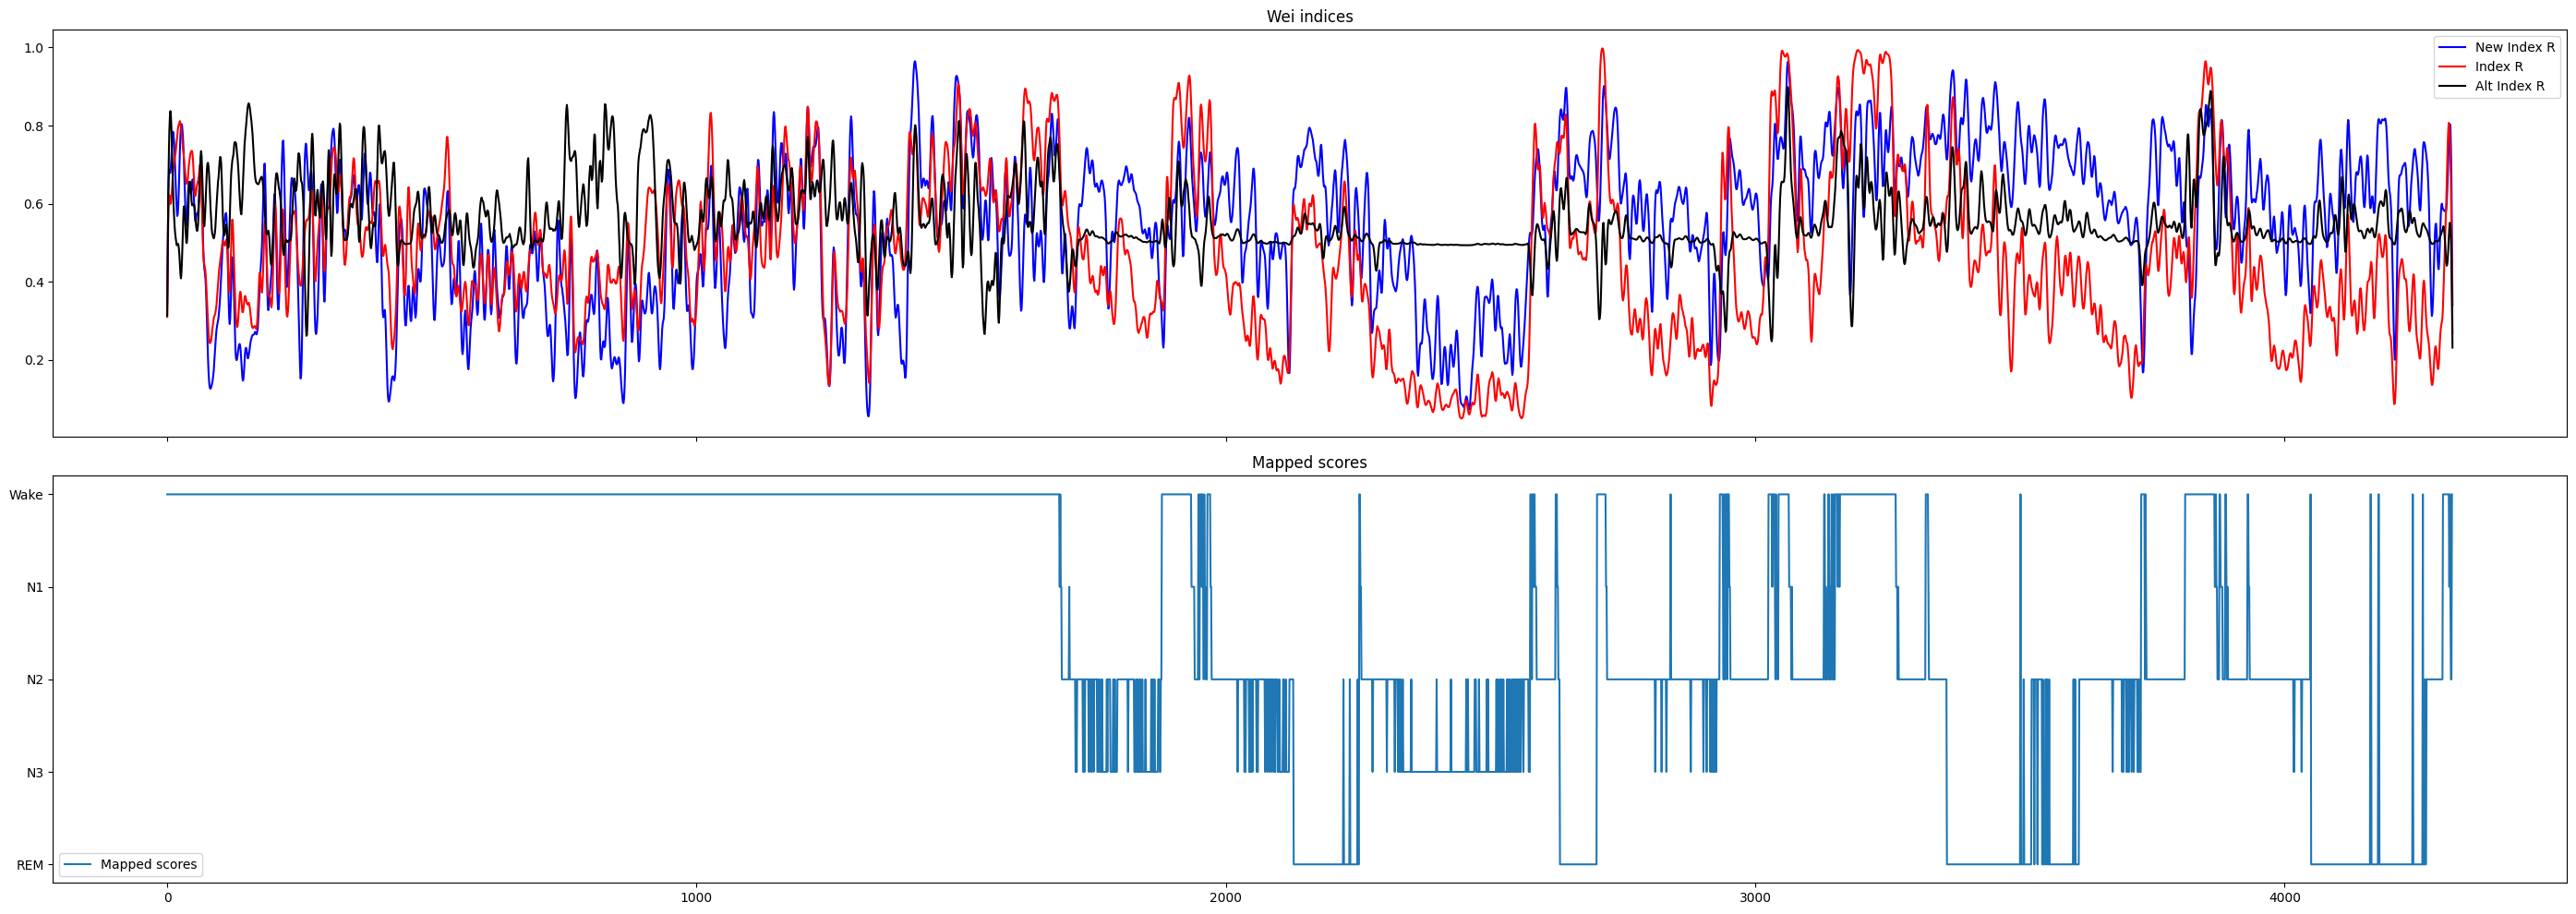

In [117]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (28, 10))
# Plot data on each subplot
ax1.plot(epochs, nindex_r_smoothed, label='New Index R', color='blue')
ax1.plot(epochs, index_r_smoothed, label='Index R', color='red')
ax1.plot(epochs, alt_index_r_smoothed, label='Alt Index R', color='black')

ax2.plot(hypno_epochs, mapped_scores, label='Mapped scores')


# Add legends
ax1.legend()
ax2.legend()


# Add titles
ax1.set_title('Wei indices')
ax2.set_title('Mapped scores')
ax2.set_yticks([0, 1, 2, 3, 4])
ax2.set_yticklabels(state_labels)
ax2.invert_yaxis() 
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(f"{output_dir}/Wei_indices_original.svg", format='svg')
# Show the plots
plt.show()